# Project work part 1

- author: Mehdi Jamali

## Links
- GitHub: [Click here](https://github.com/Mehdij1511/IND320-Mehdij1511)
- Streamlit: [Click here](https://ind320mehdij1511.streamlit.app/)

## Declaration of AI usage

The following AI tools were used in the development of this project:
- **Github Copilot:**
    - Used for code completion and suggestions, and to see how long I have come in the project.
- **Gemini:**
    - Used for providing coding assistance on various topics. List up functions and methods that can be used in the project. 
- **NotebookLM(Gemini):**
    - Used as a personal research assistant to answer questions and provide explanations related to the project.

The code suggestions and completions were tested, adapted, then used.

**The AI tools were used whitin the guidelines "K3 - Full use of AI" at NMBU.**

## Work log

I worked on Part 1 of the IND320 project using both Jupyter Notebook and Streamlit. I started by loading the `reservoirs.csv` dataset with Pandas. The dataset contained Norwegian column names, so I renamed them to clear English names, including date, area type, area number, year, week, filling level, capacity, filled volume, and change from the previous week. I also converted the date column to the correct datetime format so it could be used for sorting and visualizations.

In the Jupyter Notebook, I explored the structure and contents of the dataset. I used Pandas to inspect the data and prepared it for analysis. I worked on displaying the data clearly and creating visualizations of the different variables. Because the columns have different units and scales, I considered how the variables should be plotted separately and together so that the results are easier to understand.

I also developed a Streamlit application for presenting the project. The application has a main page with information about the dataset and a sidebar for navigation. I created separate pages for the home page, data table, interactive plotting, and an additional page for future analysis. The data table page loads the reservoir data and allows users to filter the data by reservoir area and year. The interactive plotting page allows users to select an area, year, and measurement, and then view changes over time.

The project was stored in a public GitHub repository and deployed as a Streamlit application. I learned how to connect the data analysis in the notebook with the interactive presentation in Streamlit. I also gained experience with caching data, creating user controls, organizing Python files, and publishing a project online.

I cooperated with Ole Andreas Grøtting at Bikuben. I also communicated through Messenger with Ole Andreas Grøtting, Daniel Tsan, and Oliver Madsen. We discussed the project requirements, coding problems, possible solutions, and the structure of the application.

I used GitHub Copilot, Gemini, and NotebookLM as support during development. These tools helped with code suggestions, explanations, and ideas for solving programming problems. I reviewed, adapted, and tested the suggestions before using them in the project.

## Library imports

We start by importing the necessary libraries for the project:

In [3]:
import pandas as pd
import numpy as np

Next we read the dataframe and translate the headers to english:

In [8]:
# Load the reservoir observations from the data folder.
df = pd.read_csv("Data/reservoirs.csv")

# Rename the Norwegian headers to clear English.
df = df.rename(
    columns={
        "dato_Id": "date",
        "omrType": "area_type",
        "omrnr": "area_number",
        "iso_aar": "year",
        "iso_uke": "week",
        "fyllingsgrad": "filling_level",
        "kapasitet_TWh": "capacity_TWh",
        "fylling_TWh": "filled_TWh",
        "neste_Publiseringsdato": "next_publication_date",
        "fyllingsgrad_forrige_uke": "previous_week_filling_level",
        "endring_fyllingsgrad": "change_in_filling_level",
    }
)

# Convert the date column so that it can be sorted and plotted correctly.
df["date"] = pd.to_datetime(df["date"])

## Data overview

The renamed dataset is displayed below to verify that the data was loaded and prepared correctly.

In [10]:
# Display a random sample of the first rows so the imported and renamed data can be checked.
df.sample(5)

,date,area_type,area_number,year,week,filling_level,capacity_TWh,filled_TWh,next_publication_date,previous_week_filling_level,change_in_filling_level
8767,1999-10-24,NO,0,1999,42,0.885434,87.437580,77.420210,0001-01-01T00:00:00,0.900596,-0.015162
9567,2004-07-25,NO,0,2004,30,0.675566,87.437580,59.069870,0001-01-01T00:00:00,0.653257,0.022309
3906,2021-01-17,EL,1,2021,2,0.698276,6.003264,4.191935,2021-01-27T13:00:00,0.759596,-0.061320
4196,1996-04-14,EL,4,1996,15,0.374648,21.079208,7.897293,0001-01-01T00:00:00,0.398850,-0.024202
7991,1996-07-07,EL,2,1996,27,0.422905,34.043590,14.397209,0001-01-01T00:00:00,0.409468,0.013437


## Reservoir variable plots

The numeric measurements are plotted separately and then compared in one standardized plot.

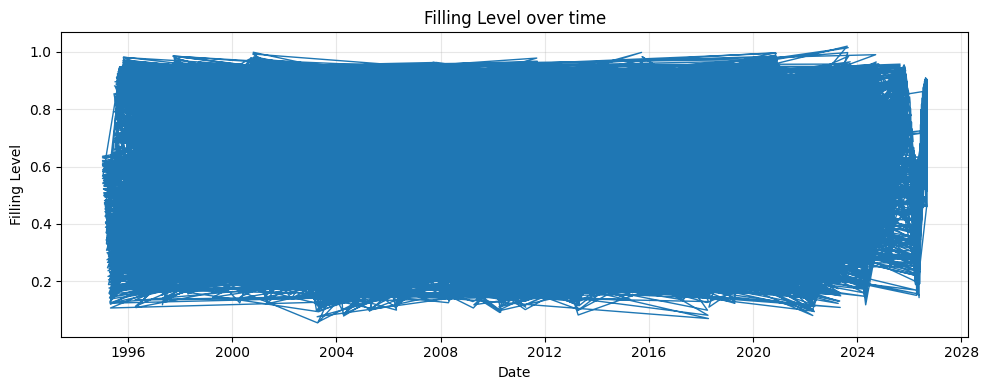

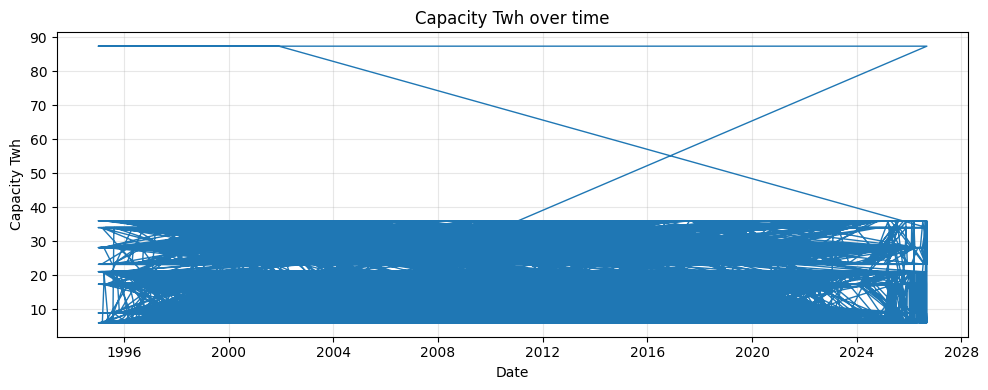

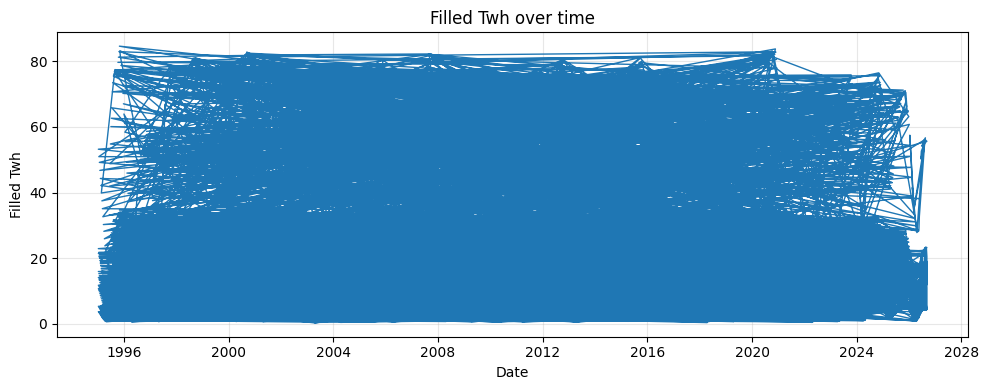

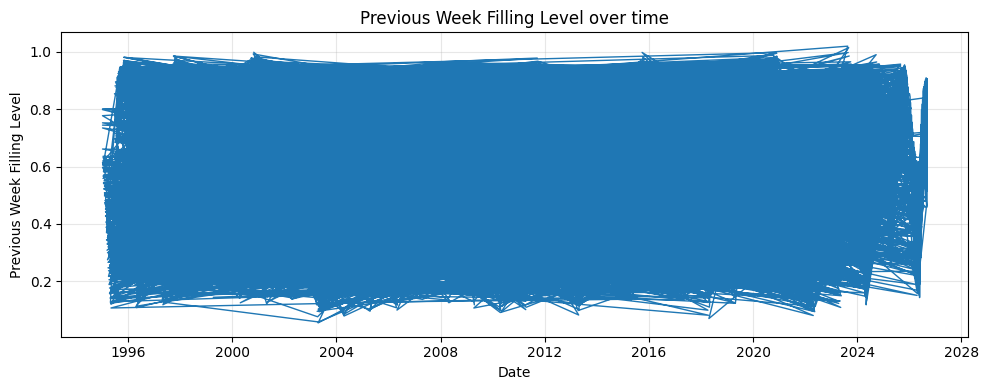

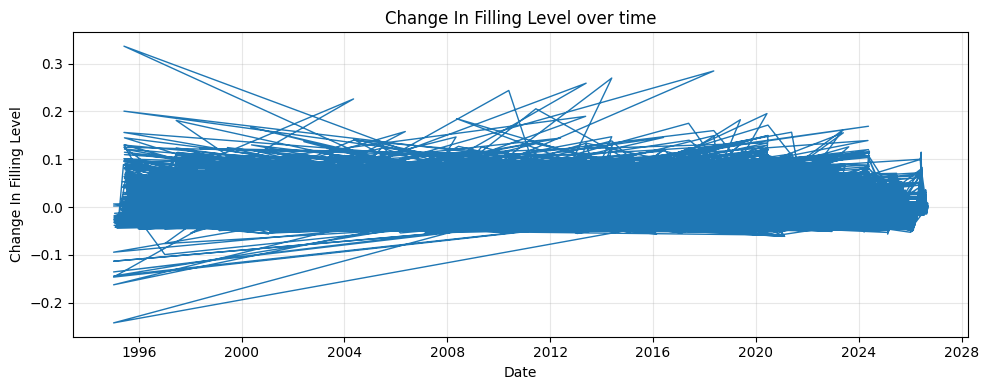

In [6]:
import matplotlib.pyplot as plt

# Select numeric measurements for plotting and exclude identifiers such as year and week.
plot_columns = [
    "filling_level",
    "capacity_TWh",
    "filled_TWh",
    "previous_week_filling_level",
    "change_in_filling_level",
]

# Plot each measurement separately against the observation date.
for column in plot_columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df["date"], df[column], linewidth=1)
    plt.title(f"{column.replace('_', ' ').title()} over time")
    plt.xlabel("Date")
    plt.ylabel(column.replace("_", " ").title())
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

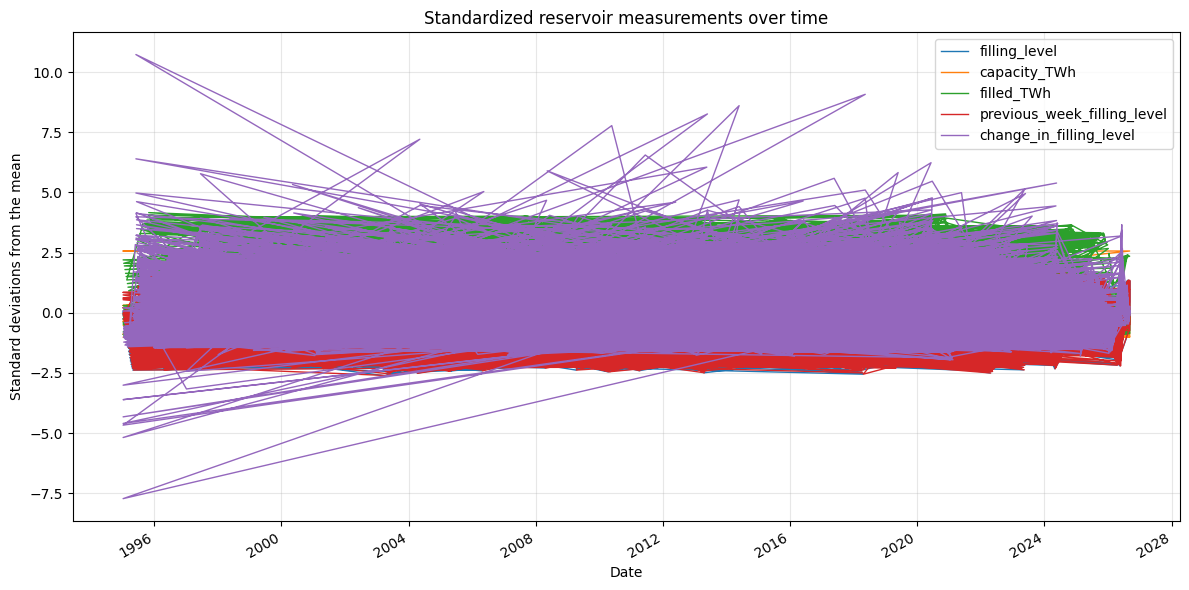

In [7]:
# Standardize the measurements so variables with different units can be compared.
standardized_data = df[plot_columns].apply(
    lambda column: (column - column.mean()) / column.std()
)
standardized_data["date"] = df["date"]

ax = standardized_data.plot(
    x="date",
    figsize=(12, 6),
    linewidth=1,
    title="Standardized reservoir measurements over time",
)
ax.set_xlabel("Date")
ax.set_ylabel("Standard deviations from the mean")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()